Perturbation on B1 of 0.1 P / application of 10% more P then indicated 

In [1]:
import pandas as pd
import pypowsybl.network as pn
import pypowsybl as pp
from pypowsybl_jupyter import nad_explorer
import re
import networkx as nx
import plotly.graph_objects as go
import plotly.express as px
import matplotlib.pyplot as plt
import numpy as np
import builtins
import itertools
import importlib
import utils

from utils import edges_with_impedance, median,cluster_subgraph,network_construction, type_controller, unique_list, plot_slack_cluster, slack_subgraph_2nd, plot_graph, dfs_slack_2nd, slack_subgraph, has_slack, visualize_graph, dfs_with_slack, median 

In [2]:
importlib.reload(utils)

<module 'utils' from 'd:\\dev\\powsybl-open-loadflow-knitro-solver\\utils.py'>

In [3]:
network_name = "test_active_power_and_correction_more_ieee/ieee300/ieee300"
network ="ieee300"

# Perturbation applied 

In [4]:
# slack_info 
pertubation = "active-perturbation"
data = pd.read_csv(
    network_name +"_" + pertubation + ".csv",
    sep=";",
    engine="python",
    index_col=False,
   # on_bad_lines="skip",
)
optim_info = pd.read_csv(
    network_name + "_" + pertubation + "_optim_info.csv",
    sep=";",
    engine="python",
    index_col=False,
)
extension_in = '.xiidm'
network = pn.load('./Outputs/' + network +"-"+pertubation + extension_in)
edges = edges_with_impedance(network)

data_grouped = data.groupby('busId')[['type','slackValue_pu','slackValue','gen','controlevoltage','transfo','shunt','load','info']].agg(unique_list)
data_grouped['Total_slack_abs'] = data_grouped['slackValue_pu'].apply(lambda x: builtins.sum(abs(slack) for slack in x) if isinstance(x, list) else abs(x))
V_nom = network.get_voltage_levels()
V_nom = pd.merge(V_nom, network.get_bus_breaker_view_buses(['bus_id','voltage_level_id','id']), left_on='id', right_on='voltage_level_id', how='left')
selected_columns = ['bus_id', 'nominal_v']
data_grouped = data_grouped.join(
    V_nom.drop_duplicates(subset='bus_id')[selected_columns].set_index('bus_id'),
    how='left'
)
G, dist, pos = network_construction(edges, data_grouped)
clusters = slack_subgraph(G, data_grouped)
data_grouped = cluster_subgraph(G, clusters, data_grouped, dist)
fig = plot_slack_cluster(G, pos, clusters,data_grouped,data, col_centroid='centroid')
fig.show()

Focal bus perturbation VL3_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL3_0_load'])
Focal bus perturbation VL319_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL319_0_load'])
Focal bus perturbation VL526_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL526_0_load'])
Focal bus perturbation VL562_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL562_0_load'])
Focal bus perturbation VL609_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL609_0_load'])
Focal bus perturbation VL92_0 is a plossible correcting bus, cluster of type V, bus with (["VoltageControl(type=GENERATOR, controlledBus='VL92_0', controllerElements=[VL92_0], mergeStatus=MAIN, mergedDependentVoltageControlsSize=0)"], ['B92-G'], [nan], [nan], ['VL92_0_load'])
Focal bus perturbation VL92_0 has dominant slac

In [5]:
plot_graph(G, pos, '[VL1_0]').show()

In [6]:
391.9002*1.1

431.09022000000004

# Correction 1 : -431.0903 P on  B3-L

In [7]:
# slack_info 
pertubation1 = "1"
data_correction2 = pd.read_csv(
    network_name +"_" + pertubation1 + ".csv",
    sep=";",
    engine="python",
    index_col=False,
   # on_bad_lines="skip",
)
# network = pn.load('./Outputs/' + network_name+"-corrected-"+pertubation1 + extension_in)
new_row = pd.read_csv(network_name+"_"+pertubation1+"_optim_info.csv", sep=";", engine="python", index_col=False)
optim_info = pd.concat([optim_info, new_row], ignore_index=True)
data_grouped_2 = data_correction2.groupby('busId')[['type','slackValue_pu','slackValue','gen','controlevoltage','transfo','shunt','load','info']].agg(unique_list)
data_grouped_2['Total_slack_abs'] = data_grouped_2['slackValue_pu'].apply(lambda x: builtins.sum(abs(slack) for slack in x) if isinstance(x, list) else abs(x))
data_grouped_2 = data_grouped_2.join(
    V_nom.drop_duplicates(subset='bus_id')[selected_columns].set_index('bus_id'),
    how='left'
)
G_2, dist, pos = network_construction(edges, data_grouped_2)
clusters = slack_subgraph(G_2, data_grouped_2)
data_grouped_2 = cluster_subgraph(G_2, clusters, data_grouped_2, dist)
fig = plot_slack_cluster(G_2, pos, clusters,data_grouped_2,data, col_centroid='centroid')
fig.show()

Focal bus perturbation VL27_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL27_0_load'])
Focal bus perturbation VL76_0 is a plossible correcting bus, cluster of type V, bus with (["VoltageControl(type=GENERATOR, controlledBus='VL76_0', controllerElements=[VL76_0], mergeStatus=MAIN, mergedDependentVoltageControlsSize=0)"], ['B76-G'], [nan], [nan], ['VL76_0_load'])
Focal bus perturbation VL76_0 has dominant slack V but no suitable controller
Focal bus perturbation VL114_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL114_0_load'])
Focal bus perturbation VL526_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL526_0_load'])
Focal bus perturbation VL528_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL528_0_load'])
Focal bus perturbation VL92_0 is a plossible correcting bus, cluster of type V, bus with (["VoltageCont

In [8]:
16.3701*1.1

18.00711

# Correction 3 : -18.0071 on B114-L

In [9]:
# slack_info 
pertubation1 = "2"
data_correction3 = pd.read_csv(
    network_name +"_" + pertubation1 + ".csv",
    sep=";",
    engine="python",
    index_col=False,
   # on_bad_lines="skip",
)
# network = pn.load('./Outputs/' + network_name+"-corrected-"+pertubation1 + extension_in)
new_row = pd.read_csv(network_name+"_"+pertubation1+"_optim_info.csv", sep=";", engine="python", index_col=False)
optim_info = pd.concat([optim_info, new_row], ignore_index=True)
data_grouped_3 = data_correction3.groupby('busId')[['type','slackValue_pu','slackValue','gen','controlevoltage','transfo','shunt','load','info']].agg(unique_list)
data_grouped_3['Total_slack_abs'] = data_grouped_3['slackValue_pu'].apply(lambda x: builtins.sum(abs(slack) for slack in x) if isinstance(x, list) else abs(x))
data_grouped_3 = data_grouped_3.join(
    V_nom.drop_duplicates(subset='bus_id')[selected_columns].set_index('bus_id'),
    how='left'
)
G_3, dist, pos = network_construction(edges, data_grouped_3)
clusters = slack_subgraph(G_3, data_grouped_3)
data_grouped_3 = cluster_subgraph(G_3, clusters, data_grouped_3, dist)
fig = plot_slack_cluster(G_3, pos, clusters,data_grouped_3,data, col_centroid='centroid')
fig.show()

Focal bus perturbation VL27_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL27_0_load'])
Focal bus perturbation VL76_0 is a plossible correcting bus, cluster of type V, bus with (["VoltageControl(type=GENERATOR, controlledBus='VL76_0', controllerElements=[VL76_0], mergeStatus=MAIN, mergedDependentVoltageControlsSize=0)"], ['B76-G'], [nan], [nan], ['VL76_0_load'])
Focal bus perturbation VL76_0 has dominant slack V but no suitable controller
Focal bus perturbation VL526_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL526_0_load'])
Focal bus perturbation VL528_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL528_0_load'])
Focal bus perturbation VL92_0 is a plossible correcting bus, cluster of type V, bus with (["VoltageControl(type=GENERATOR, controlledBus='VL92_0', controllerElements=[VL92_0], mergeStatus=MAIN, mergedDependentVoltageControlsSize=0)"], ['B9

In [10]:
11.71*1.1

12.881000000000002

# Correction 3 : -12.881 B528-L

In [11]:
# slack_info 
pertubation1 = "3"
data_correction4 = pd.read_csv(
    network_name +"_" + pertubation1 + ".csv",
    sep=";",
    engine="python",
    index_col=False,
   # on_bad_lines="skip",
)
# network = pn.load('./Outputs/' + network_name+"-corrected-"+pertubation1 + extension_in)
new_row = pd.read_csv(network_name+"_"+pertubation1+"_optim_info.csv", sep=";", engine="python", index_col=False)
optim_info = pd.concat([optim_info, new_row], ignore_index=True)
data_grouped_4 = data_correction4.groupby('busId')[['type','slackValue_pu','slackValue','gen','controlevoltage','transfo','shunt','load','info']].agg(unique_list)
data_grouped_4['Total_slack_abs'] = data_grouped_4['slackValue_pu'].apply(lambda x: builtins.sum(abs(slack) for slack in x) if isinstance(x, list) else abs(x))
data_grouped_4 = data_grouped_4.join(
    V_nom.drop_duplicates(subset='bus_id')[selected_columns].set_index('bus_id'),
    how='left'
)
G_4, dist, pos = network_construction(edges, data_grouped_4)
clusters = slack_subgraph(G_4, data_grouped_4)
data_grouped_4 = cluster_subgraph(G_4, clusters, data_grouped_4, dist)
fig = plot_slack_cluster(G_4, pos, clusters,data_grouped_4,data, col_centroid='centroid')
fig.show()

Focal bus perturbation VL27_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL27_0_load'])
Focal bus perturbation VL76_0 is a plossible correcting bus, cluster of type V, bus with (["VoltageControl(type=GENERATOR, controlledBus='VL76_0', controllerElements=[VL76_0], mergeStatus=MAIN, mergedDependentVoltageControlsSize=0)"], ['B76-G'], [nan], [nan], ['VL76_0_load'])
Focal bus perturbation VL76_0 has dominant slack V but no suitable controller
Focal bus perturbation VL526_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL526_0_load'])
Focal bus perturbation VL528_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL528_0_load'])
Focal bus perturbation VL92_0 is a plossible correcting bus, cluster of type V, bus with (["VoltageControl(type=GENERATOR, controlledBus='VL92_0', controllerElements=[VL92_0], mergeStatus=MAIN, mergedDependentVoltageControlsSize=0)"], ['B9

In [12]:
5.9492*1.1

6.54412

# Correction 4 : -6.5441 on B528-L

In [13]:
# slack_info 
pertubation1 = "4"
data_correction4 = pd.read_csv(
    network_name +"_" + pertubation1 + ".csv",
    sep=";",
    engine="python",
    index_col=False,
   # on_bad_lines="skip",
)
# network = pn.load('./Outputs/' + network_name+"-corrected-"+pertubation1 + extension_in)
new_row = pd.read_csv(network_name+"_"+pertubation1+"_optim_info.csv", sep=";", engine="python", index_col=False)
optim_info = pd.concat([optim_info, new_row], ignore_index=True)
data_grouped_4 = data_correction4.groupby('busId')[['type','slackValue_pu','slackValue','gen','controlevoltage','transfo','shunt','load','info']].agg(unique_list)
data_grouped_4['Total_slack_abs'] = data_grouped_4['slackValue_pu'].apply(lambda x: builtins.sum(abs(slack) for slack in x) if isinstance(x, list) else abs(x))
data_grouped_4 = data_grouped_4.join(
    V_nom.drop_duplicates(subset='bus_id')[selected_columns].set_index('bus_id'),
    how='left'
)
G_4, dist, pos = network_construction(edges, data_grouped_4)
clusters = slack_subgraph(G_4, data_grouped_4)
data_grouped_4 = cluster_subgraph(G_4, clusters, data_grouped_4, dist)
fig = plot_slack_cluster(G_4, pos, clusters,data_grouped_4,data, col_centroid='centroid')
fig.show()

Focal bus perturbation VL27_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL27_0_load'])
Focal bus perturbation VL76_0 is a plossible correcting bus, cluster of type V, bus with (["VoltageControl(type=GENERATOR, controlledBus='VL76_0', controllerElements=[VL76_0], mergeStatus=MAIN, mergedDependentVoltageControlsSize=0)"], ['B76-G'], [nan], [nan], ['VL76_0_load'])
Focal bus perturbation VL76_0 has dominant slack V but no suitable controller
Focal bus perturbation VL528_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL528_0_load'])
Focal bus perturbation VL92_0 is a plossible correcting bus, cluster of type V, bus with (["VoltageControl(type=GENERATOR, controlledBus='VL92_0', controllerElements=[VL92_0], mergeStatus=MAIN, mergedDependentVoltageControlsSize=0)"], ['B92-G'], [nan], [nan], ['VL92_0_load'])
Focal bus perturbation VL92_0 has dominant slack V but no suitable controller
Focal bus perturbati

In [14]:
2.9508*1.1

3.2458800000000005

# Correction 5 : -3.2459 B528-L

In [15]:
# slack_info 
pertubation1 = "5"
data_correction5 = pd.read_csv(
    network_name +"_" + pertubation1 + ".csv",
    sep=";",
    engine="python",
    index_col=False,
   # on_bad_lines="skip",
)
# network = pn.load('./Outputs/' + network_name+"-corrected-"+pertubation1 + extension_in)
new_row = pd.read_csv(network_name+"_"+pertubation1+"_optim_info.csv", sep=";", engine="python", index_col=False)
optim_info = pd.concat([optim_info, new_row], ignore_index=True)
data_grouped_5 = data_correction5.groupby('busId')[['type','slackValue_pu','slackValue','gen','controlevoltage','transfo','shunt','load','info']].agg(unique_list)
data_grouped_5['Total_slack_abs'] = data_grouped_5['slackValue_pu'].apply(lambda x: builtins.sum(abs(slack) for slack in x) if isinstance(x, list) else abs(x))
data_grouped_5 = data_grouped_5.join(
    V_nom.drop_duplicates(subset='bus_id')[selected_columns].set_index('bus_id'),
    how='left'
)
G_5, dist, pos = network_construction(edges, data_grouped_5)
clusters = slack_subgraph(G_5, data_grouped_5)
data_grouped_5 = cluster_subgraph(G_5, clusters, data_grouped_5, dist)
fig = plot_slack_cluster(G_5, pos, clusters,data_grouped_5,data, col_centroid='centroid')
fig.show()

Focal bus perturbation VL27_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL27_0_load'])
Focal bus perturbation VL76_0 is a plossible correcting bus, cluster of type V, bus with (["VoltageControl(type=GENERATOR, controlledBus='VL76_0', controllerElements=[VL76_0], mergeStatus=MAIN, mergedDependentVoltageControlsSize=0)"], ['B76-G'], [nan], [nan], ['VL76_0_load'])
Focal bus perturbation VL76_0 has dominant slack V but no suitable controller
Focal bus perturbation VL528_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL528_0_load'])
Focal bus perturbation VL92_0 is a plossible correcting bus, cluster of type V, bus with (["VoltageControl(type=GENERATOR, controlledBus='VL92_0', controllerElements=[VL92_0], mergeStatus=MAIN, mergedDependentVoltageControlsSize=0)"], ['B92-G'], [nan], [nan], ['VL92_0_load'])
Focal bus perturbation VL92_0 has dominant slack V but no suitable controller
Focal bus perturbati

<Figure size 800x400 with 0 Axes>

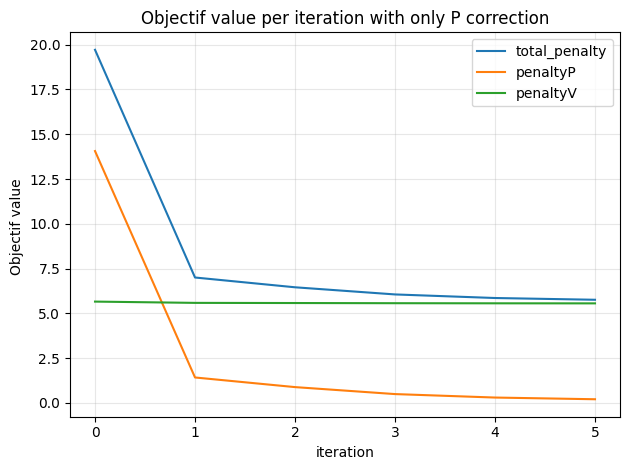

,total_penalty,penaltyP,penaltyQ,penaltyV
0,19.716704,14.061971,1.439954e-06,5.654731
1,7.000008,1.416938,4.614280e-10,5.583070
2,6.453833,0.879083,1.399093e-09,5.574750
3,6.054620,0.489545,2.166176e-09,5.565075
4,5.854994,0.295943,3.788007e-09,5.559051
5,5.756788,0.200988,3.330041e-09,5.555800


In [16]:
plt.figure(figsize=(8, 4))
optim_info[['total_penalty','penaltyP','penaltyV']].plot()
plt.title("Objectif value per iteration with only P correction")
plt.xlabel("iteration")
plt.ylabel("Objectif value ")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
optim_info

In [17]:
network.get_bus_breaker_view_buses().head()

,name,v_mag,v_angle,connected_component,synchronous_component,voltage_level_id,bus_id
id,,,,,,,
B1,1,113.522755,-113.852793,0,0,VL1,VL1_0
B2,1,120.215472,-85.929935,0,0,VL1,VL1_1
B3,1,239.794933,-87.544100,0,0,VL3,VL3_0
B4,1,371.752170,-86.144252,0,0,VL4,VL4_0
B7001,1,14.499660,-108.715315,0,0,VL7001,VL7001_0


In [18]:
edges_with_impedance(network).head()

,type,voltage_level1_id,bus1_id,connected1,voltage_level2_id,bus2_id,connected2,p1,q1,i1,p2,q2,i2,r,x,impedance,impedance_module
id,,,,,,,,,,,,,,,,,
L9001-9005-1,LINE,VL37,VL37_1,True,VL9005,VL9005_0,True,36.803611,-309.751823,1540.552242,-36.050326,313.028616,1540.552242,0.105800,0.460230,0.105800+0.460230j,0.472234
L9006-9007-1,LINE,VL9006,VL9006_0,True,VL9007,VL9007_0,True,9.114233,2.552987,819.636005,-9.065438,-2.336442,819.636005,0.024211,0.107445,0.024211+0.107445j,0.110139
L9006-9003-1,LINE,VL9006,VL9006_0,True,VL9003,VL9003_0,True,8.086632,2.150020,724.599233,-8.010349,-1.811540,724.599233,0.048430,0.214890,0.048430+0.214890j,0.220280
L9006-9003-2,LINE,VL9006,VL9006_0,True,VL9003,VL9003_0,True,8.086632,2.150020,724.599233,-8.010349,-1.811540,724.599233,0.048430,0.214890,0.048430+0.214890j,0.220280
L9012-9002-1,LINE,VL9006,VL9006_1,True,VL9002,VL9002_0,True,6.431850,1.043635,567.999313,-6.399715,-0.861139,567.999313,0.033201,0.188554,0.033201+0.188554j,0.191455


In [19]:
network.get_loads().head()

,name,type,p0,q0,p,q,i,voltage_level_id,bus_id,connected
id,,,,,,,,,,
B1-L,,UNDEFINED,2356.866,49.0,2356.866,49.0,11989.061351,VL1,VL1_0,True
B2-L,,UNDEFINED,56.000,15.0,56.000,15.0,278.428227,VL1,VL1_1,True
B3-L,,UNDEFINED,20.000,0.0,20.000,0.0,48.153667,VL3,VL3_0,True
B5-L,,UNDEFINED,353.000,130.0,353.000,130.0,1920.533904,VL5,VL5_0,True
B6-L,,UNDEFINED,120.000,41.0,120.000,41.0,609.743195,VL5,VL5_1,True


In [20]:
network.get_loads()[network.get_loads()['bus_id'] == "VL3_0"]

,name,type,p0,q0,p,q,i,voltage_level_id,bus_id,connected
id,,,,,,,,,,
B3-L,,UNDEFINED,20.0,0.0,20.0,0.0,48.153667,VL3,VL3_0,True
